# Features Selection:
> - Variance threshold
> - K-beast features(filter method)
> - Recursive feature elimination(RFE)
> - Boruta

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

%matplotlib inline

In [12]:
wine_data = load_wine()
wine_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [20]:
wine_df = pd.DataFrame(data = wine_data.data, columns = wine_data.feature_names)
wine_df['target'] = wine_data.target
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


C:\Users\aa\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 29.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\aa\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='features', ylabel='value'>

C:\Users\aa\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\aa\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 36.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


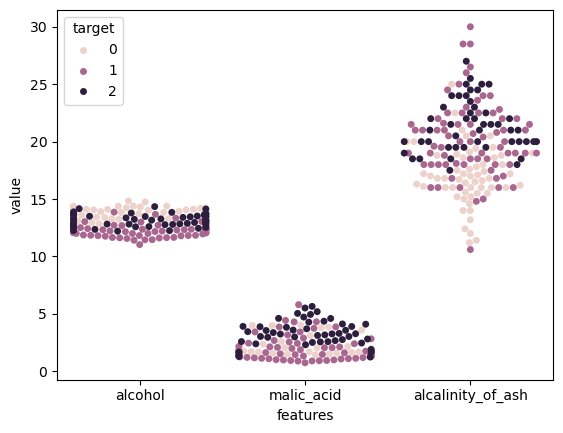

In [24]:
# هي دالة في مكتبة pandas تُستخدم لتحويل البيانات من شكل عريض (wide format) إلى شكل طويل (long format).
data_to_plot = pd.melt(wine_df[['alcohol', 'malic_acid', 'alcalinity_of_ash', 'target']],
                      id_vars='target',
                      var_name='features',
                      value_name='value')

sns.swarmplot(data=data_to_plot, x='features', y='value',hue='target')

In [48]:
wine_df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

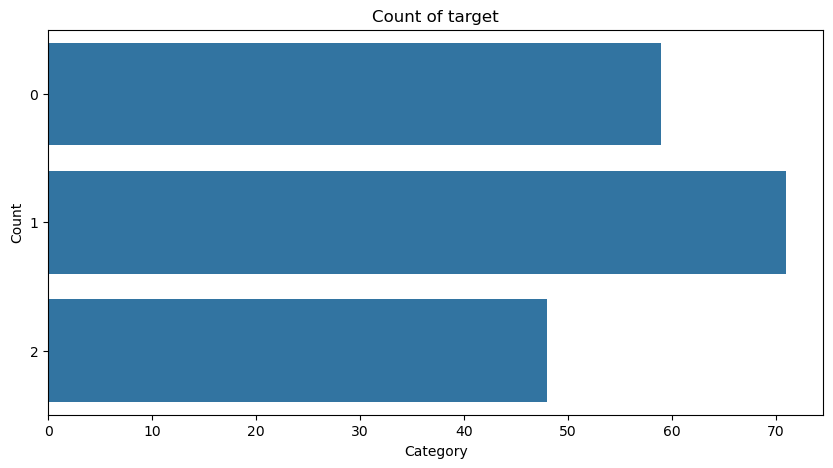

In [66]:
plt.figure(figsize=(10, 5))
plt.title("Count of target")
plt.ylabel("Count")
plt.xlabel("Category")
sns.countplot(data=wine_df, y=wine_df['target'])
plt.show()

In [68]:
from sklearn.model_selection import train_test_split
X = wine_df.drop(['target'], axis=1)
y = wine_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True,
                                                   test_size=0.3, stratify=y, random_state=42)

In [70]:
print(X_train.shape)
print(X_test.shape)

(124, 13)
(54, 13)


In [76]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

gbc = GradientBoostingClassifier(max_depth=5, random_state=42)

gbc.fit(X_train, y_train)

preds = gbc.predict(X_tes )

f1_score(y_test, preds, average='weighted')

0.9077681577681579

# 1) Variance threshold
> - اذا كان التباين قريب من الصفر تكون البيانات قريبه والعكس صحيح
> - اذا كان التباين يستوي الصفر هذا يعني انه يوجد ميزه ثابتة واذا كانت الميزه لها قيمه ثابته فهي ليست تنبؤيه لهدفك
> - يجب ان يكون للميزات نفس المقياس

In [80]:
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [82]:
X_test_v1.var(axis=0)
#  proline, magnesium   تباين عالي
#  nonflavanoid_phenol, hue   تباين منخفض

alcohol                              0.657740
malic_acid                           1.541747
ash                                  0.083185
alcalinity_of_ash                   10.391307
magnesium                          141.977987
total_phenols                        0.395481
flavanoids                           1.210991
nonflavanoid_phenols                 0.019503
proanthocyanins                      0.314681
color_intensity                      4.759191
hue                                  0.051616
od280/od315_of_diluted_wines         0.591783
proline                         110908.283718
dtype: float64

In [85]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_X_train_v1 = scaler.fit_transform(X_test_v1)

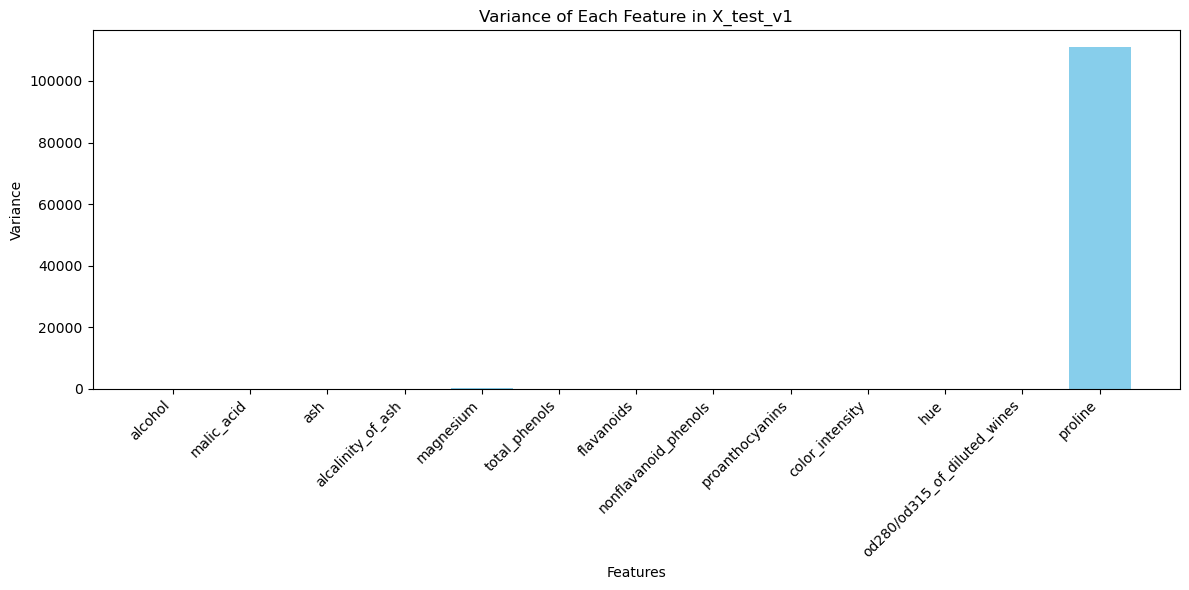

In [95]:
import matplotlib.pyplot as plt
%matplotlib inline

variance_values = X_test_v1.var(axis=0)

plt.figure(figsize=(12,6))
plt.bar(variance_values.index, variance_values.values, color='skyblue')
plt.title('Variance of Each Feature in X_test_v1')
plt.ylabel('Variance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [97]:
variance_values

alcohol                              0.657740
malic_acid                           1.541747
ash                                  0.083185
alcalinity_of_ash                   10.391307
magnesium                          141.977987
total_phenols                        0.395481
flavanoids                           1.210991
nonflavanoid_phenols                 0.019503
proanthocyanins                      0.314681
color_intensity                      4.759191
hue                                  0.051616
od280/od315_of_diluted_wines         0.591783
proline                         110908.283718
dtype: float64